# MP2

In [1]:
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
import matplotlib.pyplot as plt

In [2]:
# pyscf data
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": "aug-cc-pvqz",
}

mol = gto.M(**pyscf_args)

mf = scf.RHF(mol)

e_He = mf.kernel()
e_elec = mf.energy_elec()

mymp = mp.RMP2(mf).run()  # this is UMP2

converged SCF energy = -2.86152199563245
E(RMP2) = -2.89724612518338  E_corr = -0.0357241295509313
E(SCS-RMP2) = -2.90439095109357  E_corr = -0.0428689554611175


In [3]:
# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_res = CS_RHF(RHF_cxt)

# RHF_res.e_orb = mf.mo_energy
print(f"\nSCF energy: {RHF_res.E_RHF.real} (converged: {RHF_res.converged})")
print(f"SCF pyscf: {e_He}")
print(f"Difference: {RHF_res.E_RHF.real - e_He} \n")


SCF energy: -2.861521995632468 (converged: True)
SCF pyscf: -2.86152199563245
Difference: -1.7763568394002505e-14 



In [4]:
# %%timeit
# mp_results = CS_MP2(RHF_res)

# print(f'\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}')
# print(f'MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}')
# print(f'Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}\n')


In [5]:
# %%timeit
# n_mp_results = naive_CS_MP2(RHF_res)

In [6]:
mp_results = CS_MP2(RHF_res)
n_mp_results = naive_CS_MP2(RHF_res)

In [7]:
print(
    f"Difference between naive and tensor approach: {n_mp_results.E_MP2 - mp_results.E_MP2}"
)
print(f"\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}")
print(f"MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}")
print(
    f"Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}"
)

Difference between naive and tensor approach: -1.925929944387236e-34j


MP2 calc: (-2.912231833648643+2.9770993823791946e-19j), E_corr = (-0.05070983801617512+2.9770993823791946e-19j)
MP2 pyscf: -2.8972461251833814, E_corr = -0.03572412955093125
Differences: (-0.014985708465261371+2.9770993823791946e-19j), E_corr = (-0.014985708465243865+2.9770993823791946e-19j)


In [8]:
# E_corr_delta is 0.0014513820386715878 using PySCF's Mo energies, that compared with the current approach is
# print(
#     f"E_corr_delta using PySCFs MO energies: {mp_results.E_corr - mymp.e_corr  - 0.0014513820386715878}"
# )
# print(RHF_res.e_orb - mf.mo_energy)

In [15]:
basis = "aug-cc-pvtz"
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"{basis}",
}

atoms = [
    "He 0 0 0",
    "Mg 0 0 0",
    "Ne 0 0 0",
    "Ar 0 0 0",
    "Kr 0 0 0",
]

a_names = [i.strip().split()[0] for i in atoms]

abs_errors = []
rel_errors = []
n_electrons = []

for atom in atoms:
    pyscf_args["atom"] = atom
    mol = gto.M(**pyscf_args)

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-7

    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

converged SCF energy = -2.86118342611556
E(RMP2) = -2.89480424087096  E_corr = -0.033620814755396
E(SCS-RMP2) = -2.90152840382204  E_corr = -0.0403449777064752
converged SCF energy = -199.613350546404
E(RMP2) = -199.656548055053  E_corr = -0.0431975086497294
E(SCS-RMP2) = -199.65998293232  E_corr = -0.0466323859163391
converged SCF energy = -128.533272825199
E(RMP2) = -128.819179183706  E_corr = -0.285906358506796
E(SCS-RMP2) = -128.811646724524  E_corr = -0.27837389932491
converged SCF energy = -526.813352167186
E(RMP2) = -527.057373710039  E_corr = -0.244021542852919
E(SCS-RMP2) = -527.051593940307  E_corr = -0.238241773121227
converged SCF energy = -2752.05222324265
E(RMP2) = -2752.33874142157  E_corr = -0.286518178919284
E(SCS-RMP2) = -2752.32139028621  E_corr = -0.26916704355617


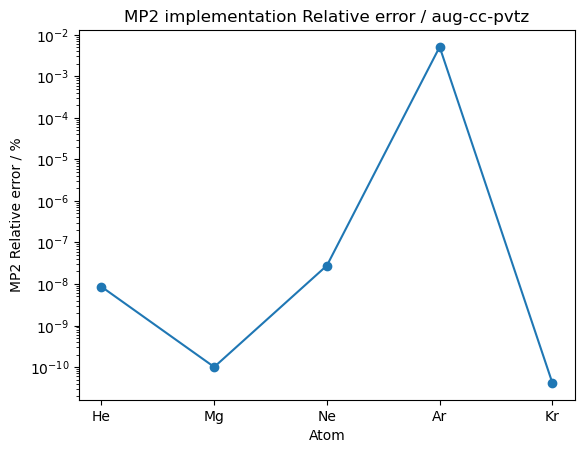

In [16]:
plt.plot(a_names, rel_errors, marker="o", linestyle="-")

plt.title(f"MP2 implementation Relative error / {basis}")
plt.yscale("log")
plt.ylabel("MP2 Relative error / %")
plt.xlabel("Atom")

plt.show()

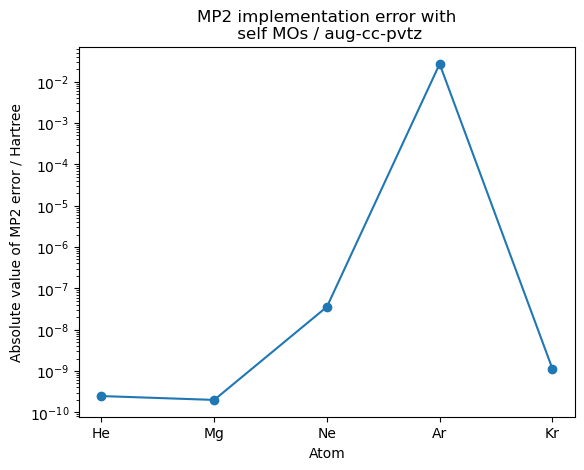

In [17]:
abs_errors = [abs(i) for i in abs_errors]
plt.plot(a_names, np.array(abs_errors).real, marker="o", linestyle="-")

plt.title(f"MP2 implementation error with\n self MOs / {basis}")
plt.yscale('log')
plt.ylabel("Absolute value of MP2 error / Hartree")
plt.xlabel("Atom")

plt.show()

# The pyscfs results

In [18]:
basis = "aug-cc-pvtz"
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"{basis}",
}

atoms = [
    "He 0 0 0",
    "Mg 0 0 0",
    "Ne 0 0 0",
    "Ar 0 0 0",
    "Kr 0 0 0",
]

a_names = [i.strip().split()[0] for i in atoms]

abs_errors = []
rel_errors = []
n_electrons = []

for atom in atoms:
    pyscf_args["atom"] = atom
    mol = gto.M(**pyscf_args)

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-7

    RHF_res = CS_RHF(RHF_cxt)
    RHF_res.R_munu = mf.mo_coeff
    
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

converged SCF energy = -2.86118342611556
E(RMP2) = -2.89480424087096  E_corr = -0.033620814755396
E(SCS-RMP2) = -2.90152840382204  E_corr = -0.0403449777064752
converged SCF energy = -199.613350546404
E(RMP2) = -199.656548055053  E_corr = -0.0431975086497298
E(SCS-RMP2) = -199.65998293232  E_corr = -0.0466323859163394
converged SCF energy = -128.533272825199
E(RMP2) = -128.819179183706  E_corr = -0.285906358506796
E(SCS-RMP2) = -128.811646724524  E_corr = -0.27837389932491
converged SCF energy = -526.813352167186
E(RMP2) = -527.057373710039  E_corr = -0.244021542852919
E(SCS-RMP2) = -527.051593940307  E_corr = -0.238241773121226
converged SCF energy = -2752.05222324266
E(RMP2) = -2752.33874142158  E_corr = -0.286518178919286
E(SCS-RMP2) = -2752.32139028621  E_corr = -0.269167043556172


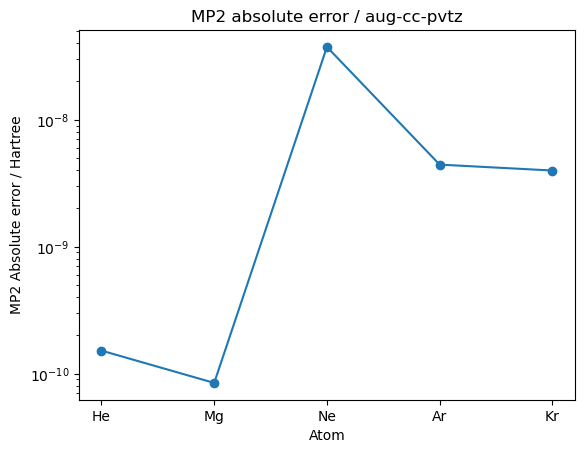

In [19]:
abs_errors = [abs(e) for e in abs_errors]
plt.plot(a_names, abs_errors, marker="o", linestyle="-")

plt.title(f"MP2 absolute error / {basis}")
plt.yscale("log")
plt.ylabel("MP2 Absolute error / Hartree")
plt.xlabel("Atom")

plt.show()

In [14]:
print(abs_errors)

[np.float64(1.6054535478815524e-10), np.float64(6.632774329773383e-10), np.float64(2.7546406045075855e-08), np.float64(3.4387994674034417e-09), np.float64(1.2275449989829212e-08)]


The result difference is:
|Atom| $MP2$ Energy Error  |
|----|---------------------|
|$He$| $1.6 \cdot 10^{-10}$|
|$Mg$| $8.1 \cdot 10^{-8}$ |
|$Ne$| $4.2 \cdot 10^{-6}$ |
|$Ar$| $3.4 \cdot 10^{-9}$ |
|$Kr$| $1.2 \cdot 10^{-8}$ |